### 1. Setup

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from IPython.display import display

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

In [ ]:
ALGOS = ['mcsplit', 'rl', 'll']
DATA_DIR = Path('../../hpc/cross-dataset-evaluation/results')

COLS = [
    'instance_a', 'instance_b', 'algo',
    'unified_size', 'unified_edges', 'unified_nodes', 'unified_time',
    'unified_aborted', 'unified_nodes_to_best',
    'unified_time_to_best', 'unified_cut_branches', 'unified_bound_pruned',
    'unified_sym_pruned'
]

In [26]:
dfs = []
for algo in ALGOS:
    path = DATA_DIR / f'{algo}_lv_all.csv'
    if not path.exists():
        print(f'WARNING: {path} not found, skipping {algo}')
        continue
    df = pd.read_csv(path, header=None, names=COLS)
    dfs.append(df)
    print(f'Loaded {algo}: {len(df)} rows')

all_data = pd.concat(dfs, ignore_index=True)

# Type coercions
for col in ['unified_size', 'unified_aborted', 'unified_time']:
    all_data[col] = pd.to_numeric(all_data[col], errors='coerce')

print(f'\nTotal rows loaded: {len(all_data)}')

Loaded mcsplit: 6105 rows
Loaded rl: 6105 rows
Loaded ll: 6105 rows

Total rows loaded: 18315


### 3. Per-Algorithm Completion Summary

In [27]:
summary_rows = []
for algo in ALGOS:
    sub = all_data[all_data['algo'] == algo]
    if sub.empty:
        continue
    total = len(sub)
    row = {
        'algo': algo,
        'total': total,
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('algo')

In [28]:
print(summary_df.round(3))

         total
algo          
mcsplit   6105
rl        6105
ll        6105


### 4. Cross-Algorithm Correctness Check

`INSUFFICIENT_DATA` means there are fewer than two algorithms that have solved that instance.

In [29]:
completed = all_data[
    (all_data['unified_aborted'] == 0) &
    (all_data['unified_size'].notna())
][['instance_a', 'instance_b', 'algo', 'unified_size']]

pivot = completed.pivot_table(
    index=['instance_a', 'instance_b'],
    columns='algo',
    values='unified_size',
    aggfunc='first'
)

def classify(row):
    vals = row.dropna()
    if len(vals) < 2:
        return 'INSUFFICIENT_DATA'
    if vals.nunique() > 1:
        return 'REAL_MISMATCH'
    return 'OK'

pivot['status'] = pivot.apply(classify, axis=1)
status_counts = pivot['status'].value_counts()

In [30]:
pivot

algo                        ll  mcsplit     rl             status
instance_a instance_b                                            
g10        g17          32.000   32.000 32.000                 OK
           g18          32.000   32.000 32.000                 OK
           g21           6.000    6.000  6.000                 OK
           g32           3.000    3.000  3.000                 OK
           g35             NaN   34.000 34.000                 OK
...                        ...      ...    ...                ...
g9         g58          36.000      NaN    NaN  INSUFFICIENT_DATA
           g60          37.000      NaN    NaN  INSUFFICIENT_DATA
           g63          36.000   36.000 36.000                 OK
           g73          37.000   37.000 37.000                 OK
g98        g99        1999.000      NaN    NaN  INSUFFICIENT_DATA

[984 rows x 4 columns]

In [31]:
print(len(pivot[pivot['status'] == "OK"]))

932


In [32]:
print(len(pivot[pivot['status'] == "INSUFFICIENT_DATA"]))

52


In [33]:
print(len(pivot[pivot['status'] == "REAL_MISMATCH"]))

0


In [34]:
mismatches = pivot[pivot['status'] == 'REAL_MISMATCH']
if mismatches.empty:
    print('\nZero real mismatches - all completed algorithms agree on every instance.')
else:
    print(f'\nREAL MISMATCHES ({len(mismatches)}):')
    display(mismatches.drop(columns='status'))


Zero real mismatches - all completed algorithms agree on every instance.


### 5. Grouping Instances by Difficulty

"Easy" instances are instances where all 7 algorithms solved it within the `EASY_THRESHOLD` limit (which is 10).

"Hard" instances are instances where all 7 algorithms were unable to solve it within the `TIMEOUT` limit (which is 1000).

"Medium" instances are everything else.

In [35]:
ALGO_ORDER = ['mcsplit', 'rl', 'll']

In [36]:
num_cols = ['unified_size', 'unified_nodes', 'unified_time', 'unified_aborted']
for col in num_cols:
    all_data[col] = pd.to_numeric(all_data[col], errors='coerce')

all_data = all_data[all_data['algo'].isin(ALGO_ORDER)].copy()

In [37]:
TIMEOUT = 1000.0
EASY_THRESHOLD = 10.0

inst_key = ['instance_a', 'instance_b']

solved = all_data.copy()

# Unified solve time (NaN if aborted)
solved['solve_time'] = solved.apply(
    lambda r: r['unified_time'] if r['unified_aborted'] == 0 else np.nan, axis=1
)

time_pivot = solved.pivot_table(
    index=inst_key, columns='algo', values='solve_time', aggfunc='first'
)
abort_pivot = solved.pivot_table(
    index=inst_key, columns='algo', values='unified_aborted', aggfunc='first'
)

# Combined abort: 1 if EITHER unified OR reference timed out, NaN treated as aborted
abort_pivot_any = (
    (abort_pivot.fillna(1).astype(int) == 1)
).astype(int)

# All unique instance pairs in the dataset
all_instances = all_data[inst_key].drop_duplicates().set_index(inst_key).index

def classify_instance(idx):
    # Check if instance exists in pivot (has at least some non-missing data)
    if idx not in abort_pivot_any.index:
        return 'hard'   # no data at all — all algos timed out, no ref data either

    row_abort = abort_pivot_any.loc[idx]
    row_time  = time_pivot.loc[idx] if idx in time_pivot.index else pd.Series(dtype=float)

    n_solved    = (row_abort == 0).sum()
    n_with_data = row_abort.notna().sum()
    n_fast      = (row_time <= EASY_THRESHOLD).sum()

    if n_solved == 0:
        return 'hard'
    if n_fast == n_with_data:
        return 'easy'
    return 'medium'

difficulty = pd.Series(
    [classify_instance(idx) for idx in all_instances],
    index=all_instances,
    name='difficulty'
)

In [38]:
print("Instance difficulty distribution (unified + reference, cross-algorithm):")
print(difficulty.value_counts())

Instance difficulty distribution (unified + reference, cross-algorithm):
difficulty
hard      5121
easy       658
medium     326
Name: count, dtype: int64


#### Unified

In [39]:
medium_instances = set(difficulty[difficulty == 'medium'].index)

# Filter all_data to just medium instances
med_mask = all_data.set_index(inst_key).index.isin(medium_instances)
medium_data = all_data[med_mask].copy()

medium_summary = medium_data.groupby('algo').apply(
    lambda x: pd.Series({
        'medium_total': len(x),
        'solved': (x['unified_aborted'] == 0).sum(),
        'solved_pct': 100 * (x['unified_aborted'] == 0).mean(),
        # 'mean_time': x.loc[x['unified_aborted'] == 0, 'unified_time'].mean(),
        # 'mean_nodes': x.loc[x['unified_aborted'] == 0, 'unified_nodes'].mean(),
    }),
    include_groups=False
).reindex(ALGO_ORDER)

In [40]:
medium_summary

,medium_total,solved,solved_pct
algo,,,
mcsplit,326.000,264.000,80.982
rl,326.000,282.000,86.503
ll,326.000,280.000,85.890


In [41]:
# Combine unified and reference medium-instance results with ranks
comparison = pd.DataFrame({
    ('Unified', 'solved'):     medium_summary['solved'],
    # ('Unified', 'solved_%'):   medium_summary['solved_pct'],
    ('Unified', 'rank'):       medium_summary['solved'].rank(ascending=False, method='min').astype(int)
}).reindex(ALGO_ORDER)

comparison.columns = pd.MultiIndex.from_tuples(comparison.columns)

In [42]:
print(f"Shared medium instance set: {int(medium_summary['medium_total'].iloc[0])} instances\n")
print(comparison)

Shared medium instance set: 326 instances

        Unified     
         solved rank
algo                
mcsplit 264.000    3
rl      282.000    1
ll      280.000    2


### 6. Overhead Analysis

Can use time per node as a proxy for per-node overhead.

Every time the search visits a node (makes a branching decision), it has to do some work. At minimum, every algorithm has to compute the bound, split the domains, and recurse. That's the baseline cost - what plain McSplit does. The RL-family algorithms do extra work on top of that: after every match, they update score tables (`lgrade`, `Q[v][w]`, DAL reward arrays), check thresholds, apply decay. RRSplit has to look up equivalence classes and check the `tried` set. SymSplit runs `break_h_sym` on candidates.

In [43]:
# Time per node (microseconds) — proxy for per-node overhead
medium_data['time_per_node_us'] = (
    medium_data['unified_time'] / medium_data['unified_nodes'] * 1e6
)

# Only on completed instances (aborted ones have truncated node counts)
completed = medium_data[medium_data['unified_aborted'] == 0]

time_per_node = completed.groupby('algo')['time_per_node_us'].agg(['mean', 'median'])

In [44]:
print("Unified time per node (microseconds):")
print(time_per_node.reindex(ALGO_ORDER).round(4))

Unified time per node (microseconds):
         mean  median
algo                 
mcsplit 0.567   0.180
rl      0.775   0.272
ll      0.742   0.294


### 8. Runtime Analysis

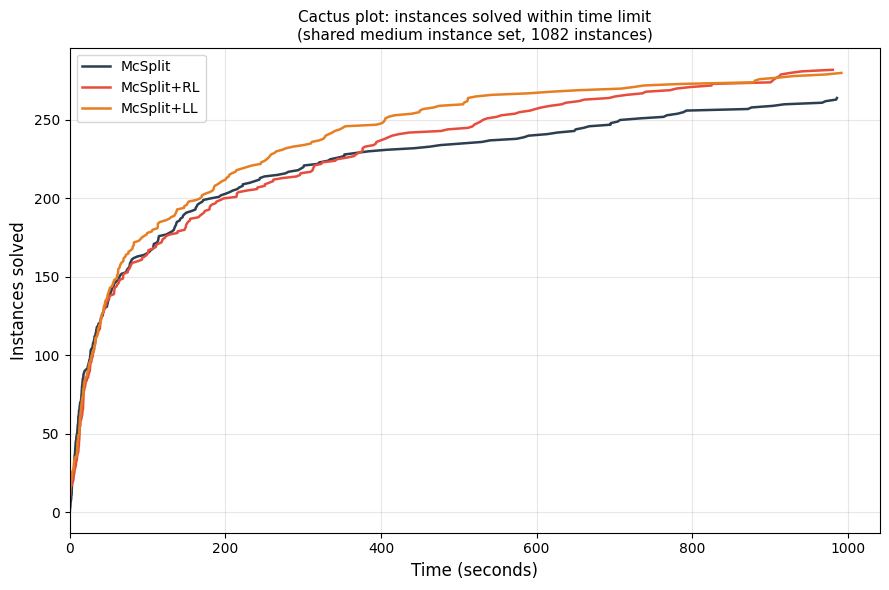

In [45]:
import matplotlib.pyplot as plt
import numpy as np

COLORS = {
    'mcsplit': '#2c3e50',
    'rl':      '#e74c3c',
    'll':      '#e67e22',
    'dal':     '#f1c40f',
    'dsb':     '#2ecc71',
    'rrsplit': '#3498db',
    'symsplit':'#9b59b6'
}
LABELS = {
    'mcsplit': 'McSplit',
    'rl':      'McSplit+RL',
    'll':      'McSplit+LL',
    'dal':     'McSplit+DAL',
    'dsb':     'McSplit+DSB',
    'rrsplit': 'RRSplit',
    'symsplit':'SymSplit'
}

# Use medium instances only for the fair comparison
medium_instances = set(difficulty[difficulty == 'medium'].index)
med_mask = all_data.set_index(inst_key).index.isin(medium_instances)
medium_data = all_data[med_mask].copy()

fig, ax = plt.subplots(figsize=(9, 6))

for algo in ALGOS:
    sub = medium_data[
        (medium_data['algo'] == algo) &
        (medium_data['unified_aborted'] == 0)
    ]['unified_time'].sort_values().values

    if len(sub) == 0:
        continue

    # x = cumulative instance count, y = time to solve that many
    x = np.arange(1, len(sub) + 1)
    ax.plot(sub, x, label=LABELS[algo], color=COLORS[algo], linewidth=1.8)

ax.set_ylabel('Instances solved', fontsize=12)
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_title('Cactus plot: instances solved within time limit\n(shared medium instance set, 1082 instances)', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(left=0)
# ax.set_ylim(bottom=0, top=TIMEOUT)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cactus_time.png', dpi=150)
plt.show()
# print("Saved: cactus_time.png")

### 9. Node Analysis

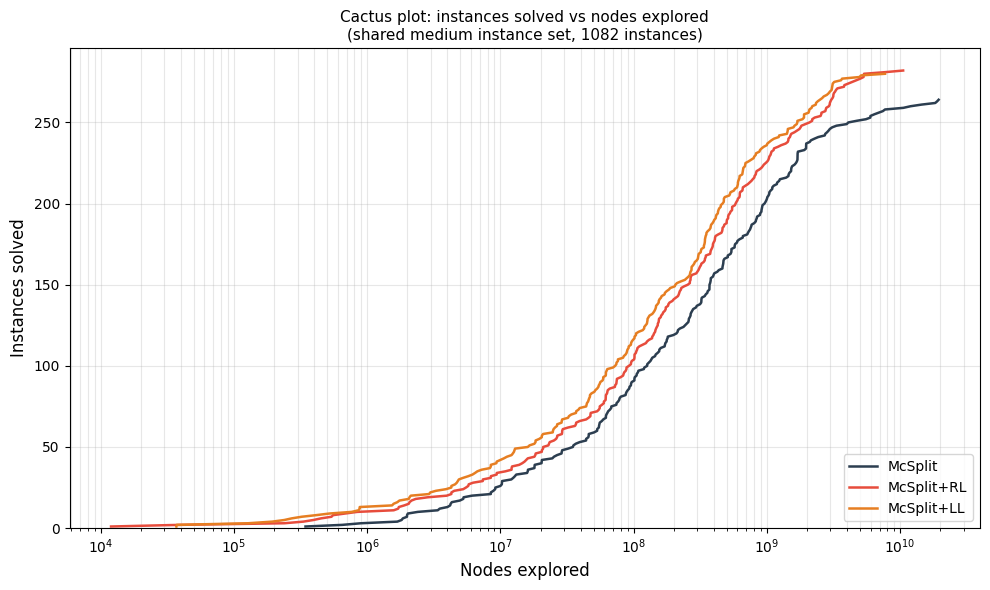

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))

for algo in ALGOS:
    sub = medium_data[
        (medium_data['algo'] == algo) &
        (medium_data['unified_aborted'] == 0)
    ]['unified_nodes'].sort_values().values

    if len(sub) == 0:
        continue

    y = np.arange(1, len(sub) + 1)
    ax.plot(sub, y, label=LABELS[algo], color=COLORS[algo], linewidth=1.8)

ax.set_xlabel('Nodes explored', fontsize=12)
ax.set_ylabel('Instances solved', fontsize=12)
ax.set_xscale('log')  # ← log scale on X (nodes), not Y
ax.set_title('Cactus plot: instances solved vs nodes explored\n(shared medium instance set, 1082 instances)', fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('cactus_nodes.png', dpi=150)
plt.show()